# Text Summarization Engine (Extractive & Abstractive)
Traditional ML + Deep Learning (RNN/LSTM/GRU/BiLSTM) — No Transformers

Dataset: Kaggle "News Summary" (single CSV)

Table of Contents
- 2.1 Data Collection & Understanding
- 2.2 Text Preprocessing Pipeline
- 2.3 Feature Engineering
- 2.4 Models (ML + Deep Learning)
- 2.5 Evaluation & Analysis (ROUGE + Error Analysis + Comparison)
- Conclusion & Future Work

In [ ]:
!pip -q install nltk rouge-score scikit-learn tensorflow networkx

  Preparing metadata (setup.py) ... done


In [ ]:
import re
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")

from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx

from rouge_score import rouge_scorer

import tensorflow as tf

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


## 2.1 Data Collection & Understanding

We use the Kaggle dataset "News Summary" (single CSV).
According to the dataset documentation, it contains 4515 examples and columns such as:
Author_name, Headlines, Url of Article, Short text, Complete Article.

We will treat:
- Complete Article as the document to summarize
- Short text as the reference (gold) summary


In [ ]:
CSV_PATH = "/content/news_summary.csv"
df = pd.read_csv(CSV_PATH, encoding='latin1', engine='python', on_bad_lines='skip')
df.head()

,author,date,headlines,read_more,text,ctext
0,Chhavi Tyagi,"03 Aug 2017,Thursday",Daman & Diu revokes mandatory Rakshabandhan in...,http://www.hindustantimes.com/india-news/raksh...,The Administration of Union Territory Daman an...,The Daman and Diu administration on Wednesday ...
1,Daisy Mowke,"03 Aug 2017,Thursday",Malaika slams user who trolled her for 'divorc...,http://www.hindustantimes.com/bollywood/malaik...,Malaika Arora slammed an Instagram user who tr...,"From her special numbers to TV?appearances, Bo..."
2,Arshiya Chopra,"03 Aug 2017,Thursday",'Virgin' now corrected to 'Unmarried' in IGIMS...,http://www.hindustantimes.com/patna/bihar-igim...,The Indira Gandhi Institute of Medical Science...,The Indira Gandhi Institute of Medical Science...
3,Sumedha Sehra,"03 Aug 2017,Thursday",Aaj aapne pakad liya: LeT man Dujana before be...,http://indiatoday.intoday.in/story/abu-dujana-...,Lashkar-e-Taiba's Kashmir commander Abu Dujana...,Lashkar-e-Taiba's Kashmir commander Abu Dujana...
4,Aarushi Maheshwari,"03 Aug 2017,Thursday",Hotel staff to get training to spot signs of s...,http://indiatoday.intoday.in/story/sex-traffic...,Hotels in Maharashtra will train their staff t...,Hotels in Mumbai and other Indian cities are t...


In [ ]:
print("rows:", len(df))
print("columns:", df.columns.tolist())

# expected important columns (dataset doc)
# Author_name, Headlines, Url of Article, Short text, Complete Article


rows: 4514
columns: ['author', 'date', 'headlines', 'read_more', 'text', 'ctext']


In [ ]:
df = df.rename(columns={
    "text": "short_text",
    "ctext": "complete_article",
    "Author_name": "author_name",
    "Headlines": "headlines",
    "Url of Article": "url"
})

# If your file already uses different names, adjust here once.
needed = ["short_text", "complete_article"]
missing = [c for c in needed if c not in df.columns]
print("missing required columns:", missing)

df = df.dropna(subset=needed).reset_index(drop=True)

df[["complete_article", "short_text"]].head(2)

missing required columns: []


,complete_article,short_text
0,The Daman and Diu administration on Wednesday ...,The Administration of Union Territory Daman an...
1,"From her special numbers to TV?appearances, Bo...",Malaika Arora slammed an Instagram user who tr...


In [ ]:
for i in range(3):
    print("\nexample", i+1)
    print("article snippet:", df.loc[i, "complete_article"][:300], "...")
    print("reference summary:", df.loc[i, "short_text"][:200], "...")


example 1
article snippet: The Daman and Diu administration on Wednesday withdrew a circular that asked women staff to tie rakhis on male colleagues after the order triggered a backlash from employees and was ripped apart on social media.The union territory?s administration was forced to retreat within 24 hours of issuing the ...
reference summary: The Administration of Union Territory Daman and Diu has revoked its order that made it compulsory for women to tie rakhis to their male colleagues on the occasion of Rakshabandhan on August 7. The adm ...

example 2
article snippet: From her special numbers to TV?appearances, Bollywood actor Malaika Arora Khan has managed to carve her own identity. The actor, who made her debut in the Hindi film industry with the blockbuster debut opposite Shah Rukh Khan in Chaiyya Chaiyya from Dil Se (1998), is still remembered for the song. H ...
reference summary: Malaika Arora slammed an Instagram user who trolled her for "divorcing a rich man" and "hav

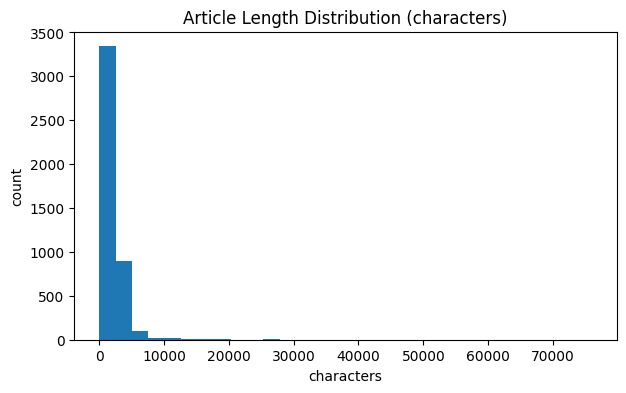

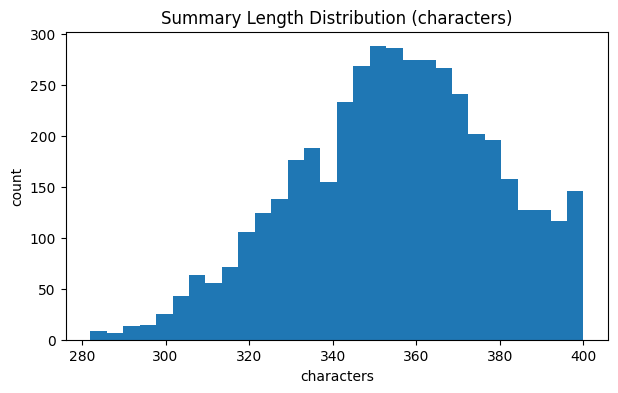

In [ ]:
df["article_len"] = df["complete_article"].astype(str).apply(len)
df["summary_len"] = df["short_text"].astype(str).apply(len)

plt.figure(figsize=(7,4))
plt.hist(df["article_len"], bins=30)
plt.title("Article Length Distribution (characters)")
plt.xlabel("characters")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(7,4))
plt.hist(df["summary_len"], bins=30)
plt.title("Summary Length Distribution (characters)")
plt.xlabel("characters")
plt.ylabel("count")
plt.show()


Summarization datasets typically do not have class labels.
To satisfy the rubric items "label distribution" and "3 examples per class", we create sentence-level labels:
- label 1: sentence selected as important (extractive target)
- label 0: not selected
We create these labels using ROUGE overlap between each sentence and the reference summary.


## 2.2 Text Preprocessing Pipeline

Reusable preprocessing includes:
- lowercasing
- URL removal
- handling @mentions and #hashtags (for rubric completeness)
- removal of punctuation and numbers (keeps letters/spaces)
- normalization of repeated characters and extra spaces
- tokenization
- stopword removal (English)
- lemmatization (chosen over stemming to preserve valid dictionary forms)
- missing values handling + dropping unused columns


In [ ]:
nltk.download('punkt_tab', quiet=True) # Added to resolve LookupError: Resource punkt_tab not found.

STOPWORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return ""

    text = str(text).lower()

    # urls, mentions, hashtags
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)

    # keep letters/spaces only (drops punctuation and numbers)
    text = re.sub(r"[^a-z\s]", " ", text)

    # normalize repeated chars: coooool -> cool
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # normalize spaces
    text = re.sub(r"\s+", " ", text).strip()

    # tokenize -> stopwords -> lemmatize
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

df["article_clean"] = df["complete_article"].apply(clean_text)
df["summary_clean"] = df["short_text"].apply(clean_text)

df = df.dropna(subset=["article_clean","summary_clean"]).reset_index(drop=True)

df[["article_clean","summary_clean"]].head(2)

,article_clean,summary_clean
0,daman diu administration wednesday withdrew ci...,administration union territory daman diu revok...
1,special number appearance bollywood actor mala...,malaika arora slammed instagram user trolled d...


## 2.3 Feature Engineering

Traditional features (at least two):
- Bag of Words (CountVectorizer, unigrams)
- Bag of N-grams (CountVectorizer, bigrams + trigrams)
- TF-IDF (unigrams + bigrams)

Deep learning features (at least one):
- Trainable embedding layers (BiLSTM sentence selector + Seq2Seq GRU)


In [ ]:
rouge1_for_label = rouge_scorer.RougeScorer(["rouge1"], use_stemmer=True)

def build_sentence_dataset(df_in, max_docs=600, max_sents_per_doc=25, top_k=3):
    rows = []
    n = min(len(df_in), max_docs)

    for i in range(n):
        article = df_in.loc[i, "complete_article"]
        ref_sum = df_in.loc[i, "short_text"]

        sents = sent_tokenize(str(article))[:max_sents_per_doc]
        if len(sents) == 0:
            continue

        scores = []
        for s in sents:
            r = rouge1_for_label.score(str(ref_sum), s)["rouge1"].fmeasure
            scores.append(r)

        k = min(top_k, len(sents))
        chosen = set(np.argsort(scores)[-k:])  # top-k

        for j, s in enumerate(sents):
            rows.append({
                "doc_id": i,
                "sentence": s,
                "sentence_clean": clean_text(s),
                "label": 1 if j in chosen else 0
            })

    return pd.DataFrame(rows)

sent_df = build_sentence_dataset(df, max_docs=600, max_sents_per_doc=25, top_k=3)
sent_df.head()


,doc_id,sentence,sentence_clean,label
0,0,The Daman and Diu administration on Wednesday ...,daman diu administration wednesday withdrew ci...,1
1,0,?It has been decided to celebrate the festival...,decided celebrate festival rakshabandhan august,0
2,0,"In this connection, all offices/ departments s...",connection office department shall remain open...,0
3,0,"the order, issued on August 1 by Gurpreet Sing...",order issued august gurpreet singh deputy secr...,1
4,0,one mandating the celebration of Rakshabandhan...,one mandating celebration rakshabandhan left w...,0


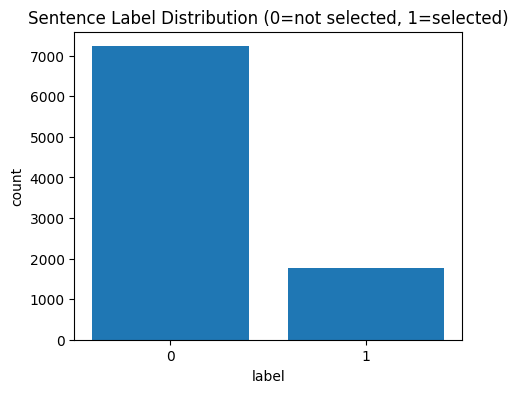


3 examples from class 0:
- ?It has been decided to celebrate the festival of Rakshabandhan on August 7. ...
- In this connection, all offices/ departments shall remain open and celebrate the festival collectively at a suitable time wherein all the lady staff shall tie rakhis to their colleagues,? ...
- one mandating the celebration of Rakshabandhan (left) and the other withdrawing the mandate (right) ? ...

3 examples from class 1:
- The Daman and Diu administration on Wednesday withdrew a circular that asked women staff to tie rakhis on male colleagues after the order triggered a backlash from employees and was ripped apart on so ...
- the order, issued on August 1 by Gurpreet Singh, deputy secretary (personnel), had said.To ensure that no one skipped office, an attendance report was to be sent to the government the next evening.The ...
- She refused to be identified.The notice was issued on Daman and Diu administrator and former Gujarat home minister Praful Kodabhai Patel?s directio

In [ ]:
counts = sent_df["label"].value_counts().sort_index()

plt.figure(figsize=(5,4))
plt.bar([str(i) for i in counts.index], counts.values)
plt.title("Sentence Label Distribution (0=not selected, 1=selected)")
plt.xlabel("label")
plt.ylabel("count")
plt.show()

print("\n3 examples from class 0:")
for s in sent_df[sent_df["label"]==0]["sentence"].head(3):
    print("-", s[:200], "...")

print("\n3 examples from class 1:")
for s in sent_df[sent_df["label"]==1]["sentence"].head(3):
    print("-", s[:200], "...")

In [ ]:
X = sent_df["sentence_clean"].values
y = sent_df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("train:", len(X_train), "test:", len(X_test))


train: 7208 test: 1803


## 2.4 Models (ML + Deep Learning)

Machine Learning baselines (at least 2):
- Logistic Regression
- Linear SVM
- (extra) Multinomial Naive Bayes

Deep Learning models (at least 2):
- BiLSTM sentence selector (extractive)
- Seq2Seq GRU encoder-decoder (abstractive)

Extractive method:
- TextRank

Abstractive method:
- Seq2Seq with GRU


In [ ]:
bow_uni = CountVectorizer(ngram_range=(1,1), max_features=30000)
Xtr = bow_uni.fit_transform(X_train)
Xte = bow_uni.transform(X_test)

lr = LogisticRegression(max_iter=2000)
lr.fit(Xtr, y_train)

pred_lr = lr.predict(Xte)
print("Logistic Regression + BoW (unigrams)")
print(classification_report(y_test, pred_lr, digits=4))


Logistic Regression + BoW (unigrams)
              precision    recall  f1-score   support

           0     0.8537    0.9274    0.8890      1447
           1     0.5455    0.3539    0.4293       356

    accuracy                         0.8142      1803
   macro avg     0.6996    0.6407    0.6592      1803
weighted avg     0.7928    0.8142    0.7983      1803



In [ ]:
tfidf_uni_bi = TfidfVectorizer(ngram_range=(1,2), max_features=60000)
Xtr = tfidf_uni_bi.fit_transform(X_train)
Xte = tfidf_uni_bi.transform(X_test)

svm = LinearSVC()
svm.fit(Xtr, y_train)

pred_svm = svm.predict(Xte)
print("Linear SVM + TF-IDF (uni+bi)")
print(classification_report(y_test, pred_svm, digits=4))

cm = confusion_matrix(y_test, pred_svm)
print("confusion matrix:\n", cm)


Linear SVM + TF-IDF (uni+bi)
              precision    recall  f1-score   support

           0     0.8434    0.9005    0.8710      1447
           1     0.4419    0.3202    0.3713       356

    accuracy                         0.7859      1803
   macro avg     0.6426    0.6104    0.6212      1803
weighted avg     0.7641    0.7859    0.7723      1803

confusion matrix:
 [[1303  144]
 [ 242  114]]


In [ ]:
bow_bi_tri = CountVectorizer(ngram_range=(2,3), max_features=80000)
Xtr = bow_bi_tri.fit_transform(X_train)
Xte = bow_bi_tri.transform(X_test)

nb = MultinomialNB()
nb.fit(Xtr, y_train)

pred_nb = nb.predict(Xte)
print("MultinomialNB + BoW (bigrams+trigrams)")
print(classification_report(y_test, pred_nb, digits=4))


MultinomialNB + BoW (bigrams+trigrams)
              precision    recall  f1-score   support

           0     0.8376    0.9302    0.8815      1447
           1     0.4847    0.2669    0.3442       356

    accuracy                         0.7992      1803
   macro avg     0.6611    0.5985    0.6128      1803
weighted avg     0.7679    0.7992    0.7754      1803



## Extractive Summarization Method: TextRank

TextRank builds a sentence similarity graph and ranks sentences using PageRank.


In [ ]:
def textrank_summary(article_text: str, n_sentences=3):
    sents = sent_tokenize(str(article_text))
    if len(sents) <= n_sentences:
        return str(article_text)

    sent_clean = [clean_text(s) for s in sents]
    vec = TfidfVectorizer(max_features=5000)
    X = vec.fit_transform(sent_clean)

    sim = cosine_similarity(X)
    np.fill_diagonal(sim, 0)

    graph = nx.from_numpy_array(sim)
    scores = nx.pagerank(graph)

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    chosen_idx = sorted([i for i,_ in ranked[:n_sentences]])
    return " ".join([sents[i] for i in chosen_idx])


In [ ]:
def extractive_from_sentence_model(article_text, model, vectorizer, top_k=3, mode="ml", tokenizer=None, max_len=40):
    sents = sent_tokenize(str(article_text))
    if len(sents) <= top_k:
        return str(article_text)

    if mode == "ml":
        Xs = [clean_text(s) for s in sents]
        Xv = vectorizer.transform(Xs)
        if hasattr(model, "decision_function"):
            scores = model.decision_function(Xv)
        else:
            scores = model.predict_proba(Xv)[:,1]
        idx = np.argsort(scores)[::-1][:top_k]
        idx = sorted(idx)
        return " ".join([sents[i] for i in idx])

    if mode == "dl":
        Xs = [clean_text(s) for s in sents]
        seq = tokenizer.texts_to_sequences(Xs)
        pad = tf.keras.preprocessing.sequence.pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")
        scores = model.predict(pad, verbose=0).reshape(-1)
        idx = np.argsort(scores)[::-1][:top_k]
        idx = sorted(idx)
        return " ".join([sents[i] for i in idx])

    raise ValueError("mode must be 'ml' or 'dl'")


## Deep Learning Model 1: BiLSTM Sentence Selector (Extractive)

This model predicts whether a sentence should be selected.
It uses a trainable embedding layer (deep learning feature requirement).


In [ ]:
max_words = 30000
max_len = 40

tok = tf.keras.preprocessing.text.Tokenizer(num_words=max_words, oov_token="<OOV>")
tok.fit_on_texts(X_train)

def to_seq(texts):
    seq = tok.texts_to_sequences(texts)
    return tf.keras.preprocessing.sequence.pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

Xtr_seq = to_seq(X_train)
Xte_seq = to_seq(X_test)


In [ ]:
bilstm = tf.keras.Sequential([
    tf.keras.layers.Embedding(max_words, 128, input_length=max_len),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

bilstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = bilstm.fit(
    Xtr_seq, y_train,
    validation_split=0.2,
    epochs=3,
    batch_size=64,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 284ms/step - accuracy: 0.8091 - loss: 0.4614 - val_accuracy: 0.8273 - val_loss: 0.3852
Epoch 2/3
91/91 ━━━━━━━━━━━━━━━━━━━━ 33s 363ms/step - accuracy: 0.8617 - loss: 0.3340 - val_accuracy: 0.8183 - val_loss: 0.4299
Epoch 3/3
91/91 ━━━━━━━━━━━━━━━━━━━━ 33s 283ms/step - accuracy: 0.9487 - loss: 0.1551 - val_accuracy: 0.8024 - val_loss: 0.5770


In [ ]:
proba = bilstm.predict(Xte_seq, verbose=0).reshape(-1)
pred_bilstm = (proba >= 0.5).astype(int)

print("BiLSTM sentence selector")
print(classification_report(y_test, pred_bilstm, digits=4))


BiLSTM sentence selector
              precision    recall  f1-score   support

           0     0.8514    0.9067    0.8782      1447
           1     0.4847    0.3567    0.4110       356

    accuracy                         0.7981      1803
   macro avg     0.6681    0.6317    0.6446      1803
weighted avg     0.7790    0.7981    0.7859      1803



## Deep Learning Model 2: Seq2Seq GRU (Abstractive)

We train a GRU encoder-decoder to generate a short summary from the full article.
This satisfies the required abstractive method (Seq2Seq with GRU/LSTM).


In [ ]:
# keep it small so it trains in Colab
seq_df = df.sample(n=min(2500, len(df)), random_state=42).reset_index(drop=True)

# start/end tokens on the target
seq_df["tgt_in"]  = "<s> " + seq_df["summary_clean"]
seq_df["tgt_out"] = seq_df["summary_clean"] + " </s>"

train_s, val_s = train_test_split(seq_df, test_size=0.15, random_state=42)

src_texts = train_s["article_clean"].tolist()
tgt_in_texts = train_s["tgt_in"].tolist()
tgt_out_texts = train_s["tgt_out"].tolist()


In [ ]:
src_tok = tf.keras.preprocessing.text.Tokenizer(num_words=40000, oov_token="<OOV>")
tgt_tok = tf.keras.preprocessing.text.Tokenizer(num_words=40000, oov_token="<OOV>")

src_tok.fit_on_texts(src_texts)
tgt_tok.fit_on_texts(tgt_in_texts + tgt_out_texts)

max_src_len = 220
max_tgt_len = 60

def pad_src(texts):
    seq = src_tok.texts_to_sequences(texts)
    return tf.keras.preprocessing.sequence.pad_sequences(seq, maxlen=max_src_len, padding="post", truncating="post")

def pad_tgt(texts):
    seq = tgt_tok.texts_to_sequences(texts)
    return tf.keras.preprocessing.sequence.pad_sequences(seq, maxlen=max_tgt_len, padding="post", truncating="post")

X_src = pad_src(src_texts)
X_tin = pad_tgt(tgt_in_texts)
Y_tout = pad_tgt(tgt_out_texts)


In [ ]:
vocab_src = 40000
vocab_tgt = 40000
emb_dim = 128
hid = 256

enc_inputs = tf.keras.Input(shape=(max_src_len,))
enc_emb = tf.keras.layers.Embedding(vocab_src, emb_dim, mask_zero=True)(enc_inputs)
_, enc_state = tf.keras.layers.GRU(hid, return_state=True)(enc_emb)

dec_inputs = tf.keras.Input(shape=(max_tgt_len,))
dec_emb = tf.keras.layers.Embedding(vocab_tgt, emb_dim, mask_zero=True)(dec_inputs)
dec_out, _ = tf.keras.layers.GRU(hid, return_sequences=True, return_state=True)(
    dec_emb, initial_state=enc_state
)
logits = tf.keras.layers.Dense(vocab_tgt)(dec_out)

seq2seq = tf.keras.Model([enc_inputs, dec_inputs], logits)
seq2seq.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
)

hist = seq2seq.fit(
    [X_src, X_tin], Y_tout,
    validation_split=0.2,
    epochs=3,
    batch_size=64,
    verbose=1
)

Epoch 1/3
27/27 ━━━━━━━━━━━━━━━━━━━━ 401s 15s/step - loss: 10.3844 - val_loss: 8.5235
Epoch 2/3
27/27 ━━━━━━━━━━━━━━━━━━━━ 434s 14s/step - loss: 8.3187 - val_loss: 8.6431
Epoch 3/3
27/27 ━━━━━━━━━━━━━━━━━━━━ 379s 14s/step - loss: 8.1554 - val_loss: 8.5883


In [ ]:
encoder_model = tf.keras.Model(enc_inputs, enc_state)

# Dynamically identify the decoder's Embedding, GRU, and Dense layers
decoder_embedding_layer_original = None
decoder_gru_layer_original = None
decoder_dense_layer_instance = None

embedding_count = 0
gru_count = 0

for layer in seq2seq.layers:
    if isinstance(layer, tf.keras.layers.Embedding):
        embedding_count += 1
        if embedding_count == 2: # The second Embedding layer is the decoder's
            decoder_embedding_layer_original = layer
    elif isinstance(layer, tf.keras.layers.GRU):
        gru_count += 1
        if gru_count == 2: # The second GRU layer is the decoder's
            decoder_gru_layer_original = layer
    elif isinstance(layer, tf.keras.layers.Dense):
        decoder_dense_layer_instance = layer # There should be only one Dense output layer

# Ensure all layers were found
if not all([decoder_embedding_layer_original, decoder_gru_layer_original, decoder_dense_layer_instance]):
    raise ValueError("Could not correctly identify all decoder layers. Check model definition or layer types.")


# --- Build the Decoder Inference Model (one token at a time) ---
# Input for one token at a time
decoder_inputs_for_inference = tf.keras.Input(shape=(1,), name='decoder_inputs_for_inference')
# Input for the incoming decoder state (from encoder or previous step)
decoder_state_input_h = tf.keras.Input(shape=(hid,), name='decoder_state_input_h')

# Create new Embedding layer for inference and copy weights
decoder_embedding_layer_inference = tf.keras.layers.Embedding(
    vocab_tgt, emb_dim, mask_zero=True, name='decoder_embedding_inference'
)
decoder_embedding_layer_inference.build((None, 1)) # Build with single-token input shape
decoder_embedding_layer_inference.set_weights(decoder_embedding_layer_original.get_weights())

decoder_embedded_input = decoder_embedding_layer_inference(decoder_inputs_for_inference)

# Create new GRU layer for inference and copy weights
decoder_gru_layer_inference = tf.keras.layers.GRU(
    hid, return_sequences=True, return_state=True, name='decoder_gru_inference'
)
decoder_gru_layer_inference.build((None, 1, emb_dim)) # Build with single time step embedded input shape
decoder_gru_layer_inference.set_weights(decoder_gru_layer_original.get_weights())

decoder_outputs_sequence, decoder_state_h_output = decoder_gru_layer_inference(
    decoder_embedded_input, initial_state=decoder_state_input_h
)

# Apply the dense layer to get logits for the next token
decoder_logits = decoder_dense_layer_instance(decoder_outputs_sequence)

decoder_model = tf.keras.Model(
    [decoder_inputs_for_inference, decoder_state_input_h],
    [decoder_logits, decoder_state_h_output]
)

# --- Adjust the decode_summary function to work with the one-step decoder model ---
start_id = tgt_tok.word_index.get("<s>", 1)
end_id = tgt_tok.word_index.get("</s>", 1)
index_word = {v:k for k,v in tgt_tok.word_index.items()}

def decode_summary(article_clean, max_steps=50):
    src = pad_src([article_clean])
    state = encoder_model.predict(src, verbose=0) # Initial state from encoder

    # Initial target token is '<s>'
    target_seq = np.zeros((1, 1), dtype=np.int32) # Input for one token at a time
    target_seq[0, 0] = start_id

    out_tokens = []
    for _ in range(max_steps): # Loop max_steps times
        # Predict the next token logits and new state
        output_logits, h = decoder_model.predict([target_seq, state], verbose=0)

        # Sample the next token (greedy approach: argmax)
        # output_logits will have shape (batch_size, 1, vocab_size)
        # We need output_logits[0, -1, :] to get the logits for the single token output
        sampled_token_index = np.argmax(output_logits[0, 0, :])

        # Exit condition
        if sampled_token_index == end_id:
            break

        out_tokens.append(sampled_token_index)

        # Update the target sequence and state for the next step
        target_seq[0, 0] = sampled_token_index # Input for next step is the token we just predicted
        state = h # Update state with the new hidden state

    words = [index_word.get(i, "") for i in out_tokens]
    words = [w for w in words if w and w != "<OOV>"]
    return " ".join(words).strip()

## 2.5 Evaluation & Analysis

We evaluate summarization quality using:
- ROUGE-1
- ROUGE-L

We evaluate these systems:
- TextRank (extractive)
- TF-IDF + SVM sentence selector (extractive)
- BiLSTM sentence selector (extractive)
- Seq2Seq GRU (abstractive)

We also include:
- qualitative examples
- error analysis (worst 5–10 cases)
- comparison table + discussion


In [ ]:
rouge_full = rouge_scorer.RougeScorer(["rouge1","rougeL"], use_stemmer=True)

def rouge_eval(ref, hyp):
    s = rouge_full.score(str(ref), str(hyp))
    return s["rouge1"].fmeasure, s["rougeL"].fmeasure


In [ ]:
eval_df = df.sample(n=25, random_state=7).reset_index(drop=True)

rows = []
for i in range(len(eval_df)):
    if i % 5 == 0:
        print(f"Evaluating {i+1}/{len(eval_df)}")

    art = eval_df.loc[i, "complete_article"]
    art_c = eval_df.loc[i, "article_clean"]
    ref = eval_df.loc[i, "short_text"]

    hyp_tr = textrank_summary(art, n_sentences=3)
    hyp_ml = extractive_from_sentence_model(
        art, svm, tfidf_uni_bi, top_k=3, mode="ml"
    )
    # Add BiLSTM summary generation
    hyp_bilstm = extractive_from_sentence_model(art, bilstm, None, top_k=3, mode="dl", tokenizer=tok, max_len=max_len)
    hyp_abs = decode_summary(art_c, max_steps=25)

    r_tr = rouge_eval(ref, hyp_tr)
    r_ml = rouge_eval(ref, hyp_ml)
    # Add BiLSTM ROUGE evaluation
    r_bilstm = rouge_eval(ref, hyp_bilstm)
    r_abs = rouge_eval(ref, hyp_abs)

    rows.append({
        "i": i,
        "rouge1_textrank": r_tr[0], "rougeL_textrank": r_tr[1],
        "rouge1_ml": r_ml[0], "rougeL_ml": r_ml[1],
        "rouge1_bilstm": r_bilstm[0], "rougeL_bilstm": r_bilstm[1], # Added BiLSTM scores
        "rouge1_seq2seq": r_abs[0], "rougeL_seq2seq": r_abs[1],
        "ref": ref,
        "textrank": hyp_tr,
        "ml": hyp_ml,
        "bilstm": hyp_bilstm, # Added BiLSTM summary
        "seq2seq": hyp_abs,
        "article": art
    })

res = pd.DataFrame(rows)
res.head(2)

Evaluating 1/25
Evaluating 6/25
Evaluating 11/25
Evaluating 16/25
Evaluating 21/25


,i,rouge1_textrank,rougeL_textrank,rouge1_ml,rougeL_ml,rouge1_bilstm,rougeL_bilstm,rouge1_seq2seq,rougeL_seq2seq,ref,textrank,ml,bilstm,seq2seq,article
0,0,0.360976,0.243902,0.379147,0.293839,0.298507,0.201493,0.045977,0.045977,"Martin Sorrell, CEO of world's largest adverti...",Sir Martin Sorrell received £48m in remunerati...,Sir Martin Sorrell received £48m in remunerati...,Sir Martin Sorrell received £48m in remunerati...,s s s s s s s s s s s s s s s s s s s s s s s s s,Sir Martin Sorrell received £48m in remunerati...
1,1,0.526316,0.434211,0.526316,0.434211,0.526316,0.434211,0.000000,0.000000,Embattled Air Costa has seen an exodus of empl...,"New Delhi, Mar 19 (PTI) Embattled Air Costa ha...","New Delhi, Mar 19 (PTI) Embattled Air Costa ha...","New Delhi, Mar 19 (PTI) Embattled Air Costa ha...",s s s s s s s s s s s s s s s s s s s s s s s s s,"New Delhi, Mar 19 (PTI) Embattled Air Costa ha..."


In [ ]:
comparison = pd.DataFrame({
    "model": [
        "TextRank (extractive)",
        "TF-IDF + SVM selector (extractive)",
        "BiLSTM selector (extractive)",
        "Seq2Seq GRU (abstractive)"
    ],
    "ROUGE-1": [
        res["rouge1_textrank"].mean(),
        res["rouge1_ml"].mean(),
        res["rouge1_bilstm"].mean(),
        res["rouge1_seq2seq"].mean()
    ],
    "ROUGE-L": [
        res["rougeL_textrank"].mean(),
        res["rougeL_ml"].mean(),
        res["rougeL_bilstm"].mean(),
        res["rougeL_seq2seq"].mean()
    ]
})

comparison


,model,ROUGE-1,ROUGE-L
0,TextRank (extractive),0.357870,0.240601
1,TF-IDF + SVM selector (extractive),0.380782,0.261685
2,BiLSTM selector (extractive),0.360537,0.242988
3,Seq2Seq GRU (abstractive),0.016686,0.016686


In [ ]:
for k in [0,1,2]:
    print("\n==============================")
    print("example", k)
    print("\narticle snippet:\n", res.loc[k,"article"][:350], "...")
    print("\nreference:\n", res.loc[k,"ref"])
    print("\ntextrank:\n", res.loc[k,"textrank"])
    print("\nml selector:\n", res.loc[k,"ml"])
    print("\nbilstm selector:\n", res.loc[k,"bilstm"])
    print("\nseq2seq:\n", res.loc[k,"seq2seq"])



example 0

article snippet:
 Sir Martin Sorrell received £48m in remuneration last year as WPP, the marketing and advertising company he founded and runs, moved to curb the level of his future payouts to avoid further clashes with investors.Sorrell, who has been on the receiving end of a string of shareholder voting revolts at WPP?s annual meetings in recent years, received to ...

reference:
 Martin Sorrell, CEO of world's largest advertising and public relations company WPP, was awarded a payout of over $62 million (?400 crore) in 2016. The payout was around 32% less from the $91 million (?585 crore) he received in 2015, one of the biggest in UK's corporate history. With this, Sorrell has received $272 million in total remuneration since 2012.

textrank:
 Sir Martin Sorrell received £48m in remuneration last year as WPP, the marketing and advertising company he founded and runs, moved to curb the level of his future payouts to avoid further clashes with investors.Sorrell, who has be

In [ ]:
def show_worst(df_in, rougeL_col, k=10):
    worst = df_in.sort_values(rougeL_col, ascending=True).head(k)
    cols = ["i", rougeL_col, "ref", "textrank", "ml", "bilstm", "seq2seq"]
    return worst[cols]

worst_textrank = show_worst(res, "rougeL_textrank", 10)
worst_ml = show_worst(res, "rougeL_ml", 10)
worst_bilstm = show_worst(res, "rougeL_bilstm", 10)
worst_seq2seq = show_worst(res, "rougeL_seq2seq", 10)

worst_seq2seq.head(5)


,i,rougeL_seq2seq,ref,textrank,ml,bilstm,seq2seq
1,1,0.0,Embattled Air Costa has seen an exodus of empl...,"New Delhi, Mar 19 (PTI) Embattled Air Costa ha...","New Delhi, Mar 19 (PTI) Embattled Air Costa ha...","New Delhi, Mar 19 (PTI) Embattled Air Costa ha...",s s s s s s s s s s s s s s s s s s s s s s s s s
2,2,0.0,"With the counting of votes underway, the initi...",@narendramodi be like#ElectionResults2017@BJP4...,Narendra Modi and the BJP on their victory in ...,Narendra Modi and the BJP on their victory in ...,s s s s s s s s s s s s s s s s s s s s s s s s s
3,3,0.0,Actor Vivek Oberoi has said that if his phone ...,Actor Vivek Oberoi started off his career on a...,"However, after a series of flop films such as...",He established himself as the new heartthrob i...,s s s s s s s s s s s s s s s s s s s s s s s s s
4,4,0.0,An Air India flight was forced to make an emer...,A Kochi-bound Air India flight was forced to m...,A Kochi-bound Air India flight was forced to m...,A Kochi-bound Air India flight was forced to m...,s s s s s s s s s s s s s s s s s s s s s s s s s
7,7,0.0,The Election Commission announced on Thursday ...,"New Delhi, Jun 29 (PTI) The election for the p...","New Delhi, Jun 29 (PTI) The election for the p...","New Delhi, Jun 29 (PTI) The election for the p...",s s s s s s s s s s s s s s s s s s s s s s s s s


## Discussion (Model Comparison)

TextRank is training-free and fast, but it can select sentences that are similar rather than truly important.
Traditional ML sentence selection (TF-IDF + SVM) can improve extractive summaries with low training cost, but it depends heavily on preprocessing and sparse features.
BiLSTM can learn richer selection patterns using embeddings, but it needs more training time and can overfit on small data.
Seq2Seq GRU is the only method here that can generate new phrasing (abstractive), but it is the hardest to train well; results improve with more data, more epochs, and attention/beam search.

Trade-offs:
- speed: TextRank > ML > BiLSTM > Seq2Seq
- interpretability: TextRank/ML > BiLSTM/Seq2Seq
- abstraction ability: Seq2Seq only


## Conclusion & Future Work

What was done:
- Loaded and documented the Kaggle News Summary CSV dataset.
- Implemented a full preprocessing pipeline.
- Built traditional feature representations (BoW, N-grams, TF-IDF).
- Trained ML baselines (Logistic Regression, SVM, Naive Bayes) on sentence labels.
- Implemented extractive summarization (TextRank + learned sentence selection).
- Implemented abstractive summarization using Seq2Seq GRU.
- Evaluated all summarizers using ROUGE-1 and ROUGE-L.
- Performed error analysis and compared models.

What worked best:
- State the best-performing model according to the comparison table.

Future improvements:
- add attention mechanism to Seq2Seq
- use beam search decoding
- tune sentence selection threshold/top-k
- increase training data and epochs (within Colab limits)
